# CS4085 Deep Learning — Lab 2
## Planar Data Classification with One Hidden Layer

**Effat University · College of Engineering · Computer Science**
**Instructor:** Dr. Naila Marir

In this lab you will build your first neural network: a 2-class classifier with **one hidden layer**. You will see how much better it does than logistic regression on data that is not linearly separable.

### Learning outcomes
By the end of this lab you will be able to:

1. Implement a 2-class classification neural network with a single hidden layer.
2. Use units with a non-linear activation function, such as `tanh`.
3. Compute the cross-entropy loss.
4. Implement forward and backward propagation, and train the network with gradient descent.
5. Explain how the hidden-layer size and the learning rate change what the network learns.


## Table of Contents
- [1 - Packages and lab utilities](#1)
- [2 - Load the Dataset](#2) — Exercise 1
- [3 - Simple Logistic Regression](#3)
- [4 - Neural Network model](#4)
    - 4.1 Defining the neural network structure — Exercise 2 `layer_sizes`
    - 4.2 Initialize the model's parameters — Exercise 3 `initialize_parameters`
    - 4.3 Forward propagation — Exercise 4 `forward_propagation`
    - 4.4 Compute the cost — Exercise 5 `compute_cost`
    - 4.5 Backpropagation — Exercise 6 `backward_propagation`
    - 4.6 Update parameters — Exercise 7 `update_parameters`
    - 4.7 Integration — Exercise 8 `nn_model`
- [5 - Test the Model](#5) — Exercise 9 `predict`
- [6 - Tuning the hidden layer size](#6)
- [7 - The learning rate](#7)
- [8 - Performance on other datasets](#8)
- [9 - Reflection questions](#9)

<a name='1'></a>
## 1 - Packages and lab utilities

- [numpy](https://numpy.org/) is the main package for scientific computing in Python.
- [scikit-learn](https://scikit-learn.org/stable/) gives simple tools for data mining and data analysis.
- [matplotlib](https://matplotlib.org/) is a library for plotting graphs in Python.

All of these are already installed in Google Colab, so there is nothing to install.

In [1]:
# Package imports
import numpy as np
import copy
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import sklearn.linear_model

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)  # hide scikit-learn version notices

%matplotlib inline

The next cell contains everything the lab needs: the dataset loaders, `sigmoid()`, a plotting helper for decision boundaries, and **self-check tests** for each exercise. In Colab it appears collapsed. **Run it, but do not edit it.**

In [2]:
#@title Lab 2 utilities — run this cell, do not modify { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets


def sigmoid(x):
    """Sigmoid of a scalar or numpy array."""
    return 1 / (1 + np.exp(-x))


def load_planar_dataset(seed=1):
    """2-class 'flower' dataset. Returns X (2, 400) and Y (1, 400)."""
    np.random.seed(seed)
    m = 400                     # number of examples
    N = int(m / 2)              # examples per class
    D = 2                       # dimensionality
    X = np.zeros((m, D))
    Y = np.zeros((m, 1), dtype="uint8")   # labels (0 = red, 1 = blue)
    a = 4                       # maximum ray of the flower
    for j in range(2):
        ix = range(N * j, N * (j + 1))
        t = np.linspace(j * 3.12, (j + 1) * 3.12, N) + np.random.randn(N) * 0.2   # theta
        r = a * np.sin(4 * t) + np.random.randn(N) * 0.2                           # radius
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        Y[ix] = j
    return X.T, Y.T


def load_extra_datasets(N=200, seed=0):
    """Four extra 2-D toy datasets from scikit-learn (reproducible)."""
    noisy_circles = sklearn.datasets.make_circles(n_samples=N, factor=0.5, noise=0.3, random_state=seed)
    noisy_moons = sklearn.datasets.make_moons(n_samples=N, noise=0.2, random_state=seed)
    blobs = sklearn.datasets.make_blobs(n_samples=N, random_state=5, n_features=2, centers=6)
    gaussian_quantiles = sklearn.datasets.make_gaussian_quantiles(
        mean=None, cov=0.5, n_samples=N, n_features=2, n_classes=2, shuffle=True, random_state=seed)
    return noisy_circles, noisy_moons, blobs, gaussian_quantiles


def plot_decision_boundary(model, X, y):
    """Colours the plane by the class `model` predicts, then overlays the data."""
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = np.asarray(Z, dtype=float).reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel("x2")
    plt.xlabel("x1")
    plt.scatter(X[0, :], X[1, :], c=np.ravel(y), cmap=plt.cm.Spectral, edgecolors="k", linewidths=0.3)


def draw_network(n_x=2, n_h=4, n_y=1):
    """Draws the 2-layer network used in this lab."""
    fig, ax = plt.subplots(figsize=(9, 4.5))
    layers = [(n_x, "Input  $x$", "#9ecae1"), (n_h, "Hidden (tanh)  $a^{[1]}$", "#fdd49e"),
              (n_y, "Output (sigmoid)  $\\hat{y}$", "#a1d99b")]
    xs = [0, 3, 6]
    pos = []
    for (n, _, _), x in zip(layers, xs):
        ys = np.linspace(-(n - 1) / 2, (n - 1) / 2, n)
        pos.append([(x, y) for y in ys])
    for l in range(2):
        for (x0, y0) in pos[l]:
            for (x1, y1) in pos[l + 1]:
                ax.plot([x0, x1], [y0, y1], color="gray", lw=0.8, zorder=1)
    for (n, label, col), p, x in zip(layers, pos, xs):
        for (px, py) in p:
            ax.add_patch(plt.Circle((px, py), 0.3, color=col, ec="k", zorder=2))
        ax.text(x, -2.7, label, ha="center", fontsize=11)
    ax.text(1.5, 2.3, "$W^{[1]}, b^{[1]}$", ha="center", fontsize=11)
    ax.text(4.5, 2.3, "$W^{[2]}, b^{[2]}$", ha="center", fontsize=11)
    ax.set_xlim(-1.5, 7.5); ax.set_ylim(-3.1, 2.8); ax.set_aspect("equal"); ax.axis("off")
    plt.show()

# ----------------------------------------------------------------------------
# Self-check tests (replace the original grader files)
# ----------------------------------------------------------------------------
import copy as _copy
_REF = {"ls_X": [[1.624345364, -0.6117564137, -0.5281717523], [-1.072968622, 0.8654076293, -2.301538697], [1.744811764, -0.7612069009, 0.3190390961], [-0.2493703755, 1.462107937, -2.060140709], [-0.322417204, -0.3840543547, 1.133769442]], "ls_Y": [[-1.099891267, -0.1724282076, -0.8778584179], [0.04221374672, 0.5828152137, -1.100619177]], "init_out": {"W1": [[-0.004167578474, -0.0005626682723], [-0.02136196096, 0.01640270808], [-0.01793435585, -0.008417473657], [0.005028814172, -0.01245288087]], "b1": [[0.0], [0.0], [0.0], [0.0]], "W2": [[-0.01057952219, -0.009090076149, 0.005514540445, 0.02292208013]], "b2": [[0.0]]}, "fp_X": [[1.624345364, -0.6117564137, -0.5281717523], [-1.072968622, 0.8654076293, -2.301538697]], "fp_params": {"W1": [[1.744811764, -0.7612069009], [0.3190390961, -0.2493703755], [1.462107937, -2.060140709], [-0.322417204, -0.3840543547]], "b1": [[1.133769442], [-1.099891267], [-0.1724282076], [-0.8778584179]], "W2": [[0.04221374672, 0.5828152137, -1.100619177, 1.14472371]], "b2": [[0.9015907206]]}, "fp_A2": [[0.2313880199, 0.6377847025, 0.4236734877]], "fp_cache": {"Z1": [[4.784697462, -0.5923846046, 1.964156294], [-0.3140950026, -1.510872506, -0.6944631367], [4.41300638, -2.849743603, 3.796821245], [-0.9894970367, -1.012981194, 0.1763492007]], "A1": [[0.9998603425, -0.5316084729, 0.9614057188], [-0.3041578764, -0.9070937648, -0.600841547], [0.9997063178, -0.9933269758, 0.9989932207], [-0.7571477778, -0.7669922534, 0.1745435618]], "Z2": [[-1.200490224, 0.5657619898, -0.3077112795]], "A2": [[0.2313880199, 0.6377847025, 0.4236734877]]}, "cost_A2": [[0.1701482104, 0.343506498, 0.6453302609, 0.5823067435, 0.2409502881]], "cost_Y": [[1.0, 1.0, 0.0, 1.0, 0.0]], "cost_out": 0.9385297615546655, "bp_Y": [[1.0, 0.0, 1.0]], "bp_out": {"dW1": [[-0.003619268166, 0.006987791662], [-0.1957507958, 0.3290527708], [0.001948254795, -0.00385052805], [-0.1519738981, 0.7117112053]], "db1": [[0.005821274021], [-0.1850961714], [-0.002521237292], [-0.2381657117]], "dW2": [[-0.5538799981, 0.0005099246653, -0.659220427, -0.002605718546]], "db2": [[-0.23571793]]}, "up_params": {"W1": [[-0.3117836735, 0.7290039236], [0.2178207881, -0.8990917965], [-2.486780652, 0.9132515212], [1.127063726, -1.514093229]], "b1": [[1.639291083], [-0.429893603], [2.631280557], [0.60182225]], "W2": [[-0.3358816149, 1.237737843, 0.1111281668, 0.1291512479]], "b2": [[0.07612761222]]}, "up_grads": {"dW1": [[-0.1551281586, 0.6342253432], [0.8106550034, 0.354808609], [1.812590314, -1.356475804], [-0.4636319659, 0.8246538446]], "db1": [[-1.17643148], [1.56448966], [0.7127050945], [-0.1810065979]], "dW2": [[0.5341995256, -0.5866129598, -1.481853269, 0.8572476184]], "db2": [[0.9430989874]]}, "up_out": {"W1": [[-0.1256298832, -0.03206648819], [-0.754965216, -1.324862127], [-4.661889028, 2.541022486], [1.683422085, -2.503677842]], "b1": [[3.051008859], [-2.307281195], [1.776034444], [0.8190301674]], "W2": [[-0.9769210456, 1.941673395, 1.889352089, -0.8995458942]], "b2": [[-1.055591173]]}, "up_out_lr05": {"W1": [[-0.2342195942, 0.411891252], [-0.1875067136, -1.076496101], [-3.393075809, 1.591489423], [1.358879709, -1.926420151]], "b1": [[2.227506823], [-1.212138433], [2.27492801], [0.6923255489]], "W2": [[-0.6029813777, 1.531044323, 0.8520548012, -0.2994725613]], "b2": [[-0.3954218815]]}, "nn_X": [[1.690525704, -0.4659373705, 0.03282016368, 0.407516283, -0.7889230286, 0.002065572906, -0.0008903858579, -1.754724306], [1.017658006, 0.6004985159, -0.625428974, -0.1715482612, 0.5052993742, -0.2613564152, -0.2427490787, -1.453241412]], "nn_Y": [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0]], "nn_out": {"W1": [[0.1573134911, -0.2411916399], [0.3065553567, -0.4555450745], [-0.398878675, 0.5758590161], [0.5086816135, -0.7246021465]], "b1": [[-0.06804458719], [0.09120190562], [-0.2230758138], [0.3716797292]], "W2": [[0.3146489133, 0.5434567627, -0.6494934003, 0.7756297115]], "b2": [[-0.954592711]]}, "pr_X": [[0.09120471662, 1.091282733, -1.946970309, -1.386349532, -2.296491574, 2.409834303], [1.727836169, 2.204556285, 0.7948276393, 0.9764210964, -1.183427147, 1.916363611]], "pr_params": {"W1": [[-1.123326801, -0.6640354696], [-0.3783585704, -0.7916152715], [0.8595481092, -0.2307889955], [-0.0656610281, -0.2086362347]], "b1": [[1.34686857], [-0.6069527974], [-0.1742482136], [0.424051421]], "W2": [[-1.645990105, -0.48354095, 0.53546825, 1.166140486]], "b2": [[0.1616831087]]}, "pr_out": [[1.0, 1.0, 0.0, 0.0, 0.0, 1.0]]}

def _a(x):
    return np.array(x, dtype=float)

def _dict(d):
    return {k: _a(v) for k, v in d.items()}

def _close(a, b):
    try:
        return np.allclose(np.asarray(a, dtype=float), _a(b), rtol=1e-5, atol=1e-8)
    except Exception:
        return False

def _check_dict(name, got, expected, errors):
    if not isinstance(got, dict):
        errors.append(f"{name} should be a dict, got {type(got).__name__}")
        return
    for k, v in expected.items():
        if k not in got:
            errors.append(f"{name} is missing key '{k}'"); continue
        if got[k] is None:
            errors.append(f"{name}['{k}'] is None - did you complete the code?"); continue
        if np.shape(got[k]) != np.shape(v):
            errors.append(f"{name}['{k}'] has shape {np.shape(got[k])}, expected {np.shape(v)}"); continue
        if not _close(got[k], v):
            errors.append(f"{name}['{k}'] has the right shape but wrong values")

def _run(name, body):
    try:
        errors = body()
    except Exception as e:
        errors = [f"your function raised {type(e).__name__}: {e}"]
    if errors:
        print(f"\033[91m{len(errors)} test(s) failed for {name}:\033[0m")
        for e in errors:
            print("   -", e)
    else:
        print(f"\033[92mAll tests passed for {name}!\033[0m")

def dataset_shape_test(shape_X, shape_Y, m):
    def body():
        errors = []
        if tuple(shape_X or ()) != (2, 400): errors.append(f"shape_X is {shape_X}, expected (2, 400)")
        if tuple(shape_Y or ()) != (1, 400): errors.append(f"shape_Y is {shape_Y}, expected (1, 400)")
        if m != 400: errors.append(f"m is {m}, expected 400")
        return errors
    _run("Exercise 1", body)

def layer_sizes_test(target):
    def body():
        errors = []
        out = target(_a(_REF["ls_X"]), _a(_REF["ls_Y"]))
        if tuple(out) != (5, 4, 2): errors.append(f"got {out} for X (5,3), Y (2,3); expected (5, 4, 2)")
        out2 = target(np.zeros((7, 10)), np.zeros((3, 10)))
        if tuple(out2) != (7, 4, 3): errors.append(f"got {out2} for X (7,10), Y (3,10); expected (7, 4, 3) - read n_x and n_y from the shapes")
        return errors
    _run("layer_sizes", body)

def initialize_parameters_test(target):
    def body():
        errors = []
        np.random.seed(2)
        out = target(2, 4, 1)
        _check_dict("parameters", out, _REF["init_out"], errors)
        out2 = target(3, 5, 2)
        shapes = {"W1": (5, 3), "b1": (5, 1), "W2": (2, 5), "b2": (2, 1)}
        for k, s in shapes.items():
            if isinstance(out2, dict) and out2.get(k) is not None and np.shape(out2[k]) != s:
                errors.append(f"for (n_x, n_h, n_y) = (3, 5, 2), {k} has shape {np.shape(out2[k])}, expected {s}")
        if isinstance(out2, dict) and out2.get("b1") is not None and np.any(out2["b1"] != 0):
            errors.append("biases should be initialised to zeros")
        return errors
    _run("initialize_parameters", body)

def forward_propagation_test(target):
    def body():
        errors = []
        A2, cache = target(_a(_REF["fp_X"]), _dict(_REF["fp_params"]))
        if A2 is None: return ["A2 is None - did you complete the code?"]
        if np.shape(A2) != (1, 3): errors.append(f"A2 has shape {np.shape(A2)}, expected (1, 3)")
        elif not _close(A2, _REF["fp_A2"]): errors.append("A2 has wrong values")
        _check_dict("cache", cache, _REF["fp_cache"], errors)
        return errors
    _run("forward_propagation", body)

def compute_cost_test(target):
    def body():
        errors = []
        cost = target(_a(_REF["cost_A2"]), _a(_REF["cost_Y"]))
        if not isinstance(cost, float): errors.append(f"cost should be a Python float, got {type(cost).__name__}")
        if not _close(cost, _REF["cost_out"]): errors.append(f"cost = {cost}, expected {_REF['cost_out']:.8f}")
        return errors
    _run("compute_cost", body)

def backward_propagation_test(target):
    def body():
        errors = []
        grads = target(_dict(_REF["fp_params"]), _dict(_REF["fp_cache"]), _a(_REF["fp_X"]), _a(_REF["bp_Y"]))
        _check_dict("grads", grads, _REF["bp_out"], errors)
        return errors
    _run("backward_propagation", body)

def update_parameters_test(target):
    def body():
        errors = []
        params = _dict(_REF["up_params"]); original = _copy.deepcopy(params)
        out = target(params, _dict(_REF["up_grads"]))
        _check_dict("parameters (learning_rate=1.2)", out, _REF["up_out"], errors)
        for k in original:
            if not np.array_equal(params[k], original[k]):
                errors.append(f"the input parameters['{k}'] was modified in place - work on copies"); break
        out2 = target(_dict(_REF["up_params"]), _dict(_REF["up_grads"]), learning_rate=0.5)
        _check_dict("parameters (learning_rate=0.5)", out2, _REF["up_out_lr05"], errors)
        return errors
    _run("update_parameters", body)

def nn_model_test(target):
    def body():
        errors = []
        out = target(_a(_REF["nn_X"]), _a(_REF["nn_Y"]), 4, num_iterations=100, print_cost=False)
        _check_dict("parameters", out, _REF["nn_out"], errors)
        return errors
    _run("nn_model", body)

def predict_test(target):
    def body():
        errors = []
        out = target(_dict(_REF["pr_params"]), _a(_REF["pr_X"]))
        if out is None: return ["predictions is None - did you complete the code?"]
        if np.shape(out) != (1, 6): errors.append(f"predictions has shape {np.shape(out)}, expected (1, 6)")
        elif not np.array_equal(np.asarray(out, dtype=float), _a(_REF["pr_out"])):
            errors.append("predictions have wrong values (threshold is 0.5)")
        return errors
    _run("predict", body)

print("Lab 2 utilities loaded.")

Lab 2 utilities loaded.


<a name='2'></a>
## 2 - Load the Dataset

The code below loads a 2-class dataset into the variables `X` and `Y`.

In [3]:
X, Y = load_planar_dataset()

Visualize the dataset using matplotlib. The data looks like a "flower" with some red (label y=0) and some blue (y=1) points. Your goal is to build a model that fits this data: the classifier should label every region of the plane as either red or blue.

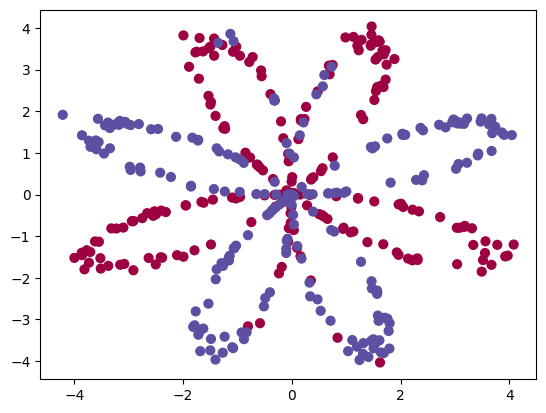

In [4]:
# Visualize the data
plt.scatter(X[0, :], X[1, :], c=Y.ravel(), s=40, cmap=plt.cm.Spectral);

You have:
- a numpy array (matrix) `X` that contains your features $(x_1, x_2)$
- a numpy array (vector) `Y` that contains your labels (red: 0, blue: 1).

First, get a better sense of what your data looks like.

<a name='ex-1'></a>
### Exercise 1

How many training examples do you have? What is the `shape` of the variables `X` and `Y`?

**Hint**: How do you get the shape of a numpy array? [(help)](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.shape.html)

In [5]:
# (≈ 3 lines of code)
# YOUR CODE STARTS HERE
shape_X = X.shape
shape_Y = Y.shape
m = X.shape[1]  # training set size
# YOUR CODE ENDS HERE

print('The shape of X is: ' + str(shape_X))
print('The shape of Y is: ' + str(shape_Y))
print('I have m = ' + str(m) + ' training examples!')

dataset_shape_test(shape_X, shape_Y, m)

The shape of X is: (2, 400)
The shape of Y is: (1, 400)
I have m = 400 training examples!
All tests passed for Exercise 1!


**Expected output**
```
The shape of X is: (2, 400)
The shape of Y is: (1, 400)
I have m = 400 training examples!
```

<a name='3'></a>
## 3 - Simple Logistic Regression

Before you build a full neural network, check how logistic regression does on this problem. Run the code below to train scikit-learn's logistic regression classifier on the dataset.

In [6]:
# Train the logistic regression classifier
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X.T, Y.ravel());

Now plot the decision boundary of this model. Run the code below.

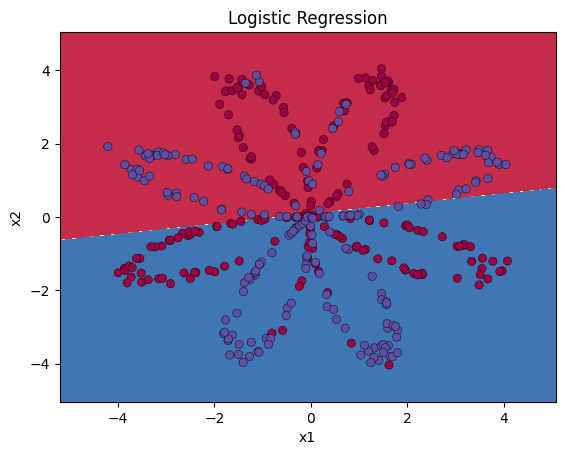

Accuracy of logistic regression: 47% (percentage of correctly labelled datapoints)


In [7]:
# Plot the decision boundary for logistic regression
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Logistic Regression")
plt.show()

# Print accuracy
LR_predictions = clf.predict(X.T)
LR_accuracy = np.mean(LR_predictions == Y.ravel()) * 100
print('Accuracy of logistic regression: %d%% (percentage of correctly labelled datapoints)' % LR_accuracy)

**Expected output**: `Accuracy of logistic regression: 47%`

**Interpretation**: The dataset is not linearly separable, so logistic regression does not do well. A neural network should do better. Let's try it now!

<a name='4'></a>
## 4 - Neural Network model

Logistic regression did not work well on the flower dataset. Next, you will train a neural network with a single hidden layer and see how it handles the same problem.

**The model** (run the cell below to draw it):

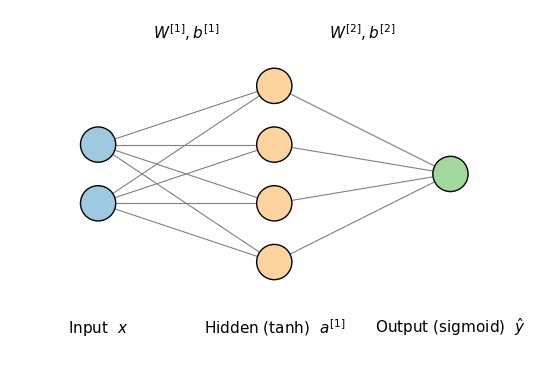

In [8]:
draw_network(n_x=2, n_h=4, n_y=1)

**Mathematically**, for one example $x^{(i)}$:

$$z^{[1] (i)} =  W^{[1]} x^{(i)} + b^{[1]}\tag{1}$$
$$a^{[1] (i)} = \tanh(z^{[1] (i)})\tag{2}$$
$$z^{[2] (i)} = W^{[2]} a^{[1] (i)} + b^{[2]}\tag{3}$$
$$\hat{y}^{(i)} = a^{[2] (i)} = \sigma(z^{ [2] (i)})\tag{4}$$
$$y^{(i)}_{prediction} = \begin{cases} 1 & \text{if } a^{[2](i)} > 0.5 \\ 0 & \text{otherwise } \end{cases}\tag{5}$$

Given the predictions on all the examples, you can compute the cost $J$:
$$J = - \frac{1}{m} \sum\limits_{i = 1}^{m} \left( y^{(i)}\log\left(a^{[2] (i)}\right) + (1-y^{(i)})\log\left(1- a^{[2] (i)}\right) \right) \tag{6}$$

**Reminder**: the general method for building a neural network is:
1. Define the network structure (number of input units, hidden units, and so on).
2. Initialize the model's parameters.
3. Loop:
    - Implement forward propagation
    - Compute the loss
    - Implement backward propagation to get the gradients
    - Update the parameters (gradient descent)

You will build a helper function for each step, then merge them into one function called `nn_model()`. Once `nn_model()` has learned the right parameters, you can make predictions on new data.

<a name='4-1'></a>
### 4.1 - Defining the neural network structure

<a name='ex-2'></a>
### Exercise 2 - layer_sizes

Define three variables:
- `n_x`: the size of the input layer
- `n_h`: the size of the hidden layer (**set this to 4**, `n_h = 4`, for this exercise only)
- `n_y`: the size of the output layer

**Hint**: Use the shapes of `X` and `Y` to find `n_x` and `n_y`.

In [9]:
def layer_sizes(X, Y):
    """
    Arguments:
    X -- input dataset of shape (input size, number of examples)
    Y -- labels of shape (output size, number of examples)

    Returns:
    n_x -- the size of the input layer
    n_h -- the size of the hidden layer
    n_y -- the size of the output layer
    """
    # (≈ 3 lines of code)
    # YOUR CODE STARTS HERE
    n_x = X.shape[0]
    n_h = 4
    n_y = Y.shape[0]
    # YOUR CODE ENDS HERE
    return (n_x, n_h, n_y)

In [10]:
t_X, t_Y = np.random.randn(5, 3), np.random.randn(2, 3)
(n_x, n_h, n_y) = layer_sizes(t_X, t_Y)
print("The size of the input layer is: n_x = " + str(n_x))
print("The size of the hidden layer is: n_h = " + str(n_h))
print("The size of the output layer is: n_y = " + str(n_y))

layer_sizes_test(layer_sizes)

The size of the input layer is: n_x = 5
The size of the hidden layer is: n_h = 4
The size of the output layer is: n_y = 2
All tests passed for layer_sizes!


**Expected output**
```
The size of the input layer is: n_x = 5
The size of the hidden layer is: n_h = 4
The size of the output layer is: n_y = 2
All tests passed for layer_sizes!
```

<a name='4-2'></a>
### 4.2 - Initialize the model's parameters

<a name='ex-3'></a>
### Exercise 3 - initialize_parameters

Implement the function `initialize_parameters()`.

**Instructions**:
- Make sure your parameters have the right sizes. Look at the network figure above if needed.
- Initialize the weight matrices with random values.
    - Use `np.random.randn(a, b) * 0.01` to create a random matrix of shape (a, b).
- Initialize the bias vectors as zeros.
    - Use `np.zeros((a, b))` to create a matrix of zeros of shape (a, b).

In [11]:
def initialize_parameters(n_x, n_h, n_y):
    """
    Arguments:
    n_x -- size of the input layer
    n_h -- size of the hidden layer
    n_y -- size of the output layer

    Returns:
    params -- python dictionary containing your parameters:
                    W1 -- weight matrix of shape (n_h, n_x)
                    b1 -- bias vector of shape (n_h, 1)
                    W2 -- weight matrix of shape (n_y, n_h)
                    b2 -- bias vector of shape (n_y, 1)
    """
    # (≈ 4 lines of code)
    # YOUR CODE STARTS HERE
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    # YOUR CODE ENDS HERE

    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    return parameters

In [12]:
np.random.seed(2)
parameters = initialize_parameters(2, 4, 1)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

initialize_parameters_test(initialize_parameters)

W1 = [[-0.00416758 -0.00056267]
 [-0.02136196  0.01640271]
 [-0.01793436 -0.00841747]
 [ 0.00502881 -0.01245288]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.01057952 -0.00909008  0.00551454  0.02292208]]
b2 = [[0.]]
All tests passed for initialize_parameters!


**Expected output**
```
W1 = [[-0.00416758 -0.00056267]
 [-0.02136196  0.01640271]
 [-0.01793436 -0.00841747]
 [ 0.00502881 -0.01245288]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.01057952 -0.00909008  0.00551454  0.02292208]]
b2 = [[0.]]
All tests passed for initialize_parameters!
```

<a name='4-3'></a>
### 4.3 - Forward propagation

<a name='ex-4'></a>
### Exercise 4 - forward_propagation

Implement `forward_propagation()` using these vectorized equations:

$$Z^{[1]} =  W^{[1]} X + b^{[1]}\tag{1}$$
$$A^{[1]} = \tanh(Z^{[1]})\tag{2}$$
$$Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}\tag{3}$$
$$\hat{Y} = A^{[2]} = \sigma(Z^{[2]})\tag{4}$$

**Instructions**:
- Use the function `sigmoid()`. It is defined in the lab utilities cell.
- Use the function `np.tanh()`. It is part of numpy.
- Steps:
    1. Get each parameter from the dictionary `parameters` (the output of `initialize_parameters()`) using `parameters[".."]`.
    2. Compute $Z^{[1]}, A^{[1]}, Z^{[2]}$ and $A^{[2]}$ (the vector of predictions for all examples in the training set).
- The values needed for backpropagation are stored in `cache`, which is passed to the backpropagation function.

In [13]:
def forward_propagation(X, parameters):
    """
    Argument:
    X -- input data of size (n_x, m)
    parameters -- python dictionary containing your parameters (output of initialize_parameters)

    Returns:
    A2 -- the sigmoid output of the second activation
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2"
    """
    # Retrieve each parameter from the dictionary "parameters"
    # (≈ 4 lines of code)
    # YOUR CODE STARTS HERE
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    # YOUR CODE ENDS HERE

    # Implement forward propagation to calculate A2 (probabilities)
    # (≈ 4 lines of code)
    # YOUR CODE STARTS HERE
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    # YOUR CODE ENDS HERE

    assert A2.shape == (1, X.shape[1])

    cache = {"Z1": Z1,
             "A1": A1,
             "Z2": Z2,
             "A2": A2}
    return A2, cache

In [14]:
A2, cache = forward_propagation(np.array(_REF["fp_X"]), {k: np.array(v) for k, v in _REF["fp_params"].items()})
print("A2 = " + str(A2))

forward_propagation_test(forward_propagation)

A2 = [[0.23138802 0.6377847  0.42367349]]
All tests passed for forward_propagation!


**Expected output**
```
A2 = [[0.23138802 0.6377847  0.42367349]]
All tests passed for forward_propagation!
```

<a name='4-4'></a>
### 4.4 - Compute the Cost

Now that you have computed $A^{[2]}$ (the Python variable `A2`), which contains $a^{[2](i)}$ for every example, you can compute the cost:

$$J = - \frac{1}{m} \sum\limits_{i = 1}^{m} \left( y^{(i)}\log\left(a^{[2] (i)}\right) + (1-y^{(i)})\log\left(1- a^{[2] (i)}\right) \right) \tag{7}$$

<a name='ex-5'></a>
### Exercise 5 - compute_cost

Implement `compute_cost()` to compute the value of the cost $J$.

**Instructions**:
- There are many ways to implement the cross-entropy loss. Here is one way to compute the part $- \sum\limits_{i=1}^{m}  y^{(i)}\log(a^{[2](i)})$ without a for loop:
```python
logprobs = np.multiply(np.log(A2), Y)
cost = - np.sum(logprobs)
```
- Use that idea to build the whole cost function.

**Notes**:
- You can use `np.multiply()` followed by `np.sum()`, or use `np.dot()` directly.
- `np.multiply` + `np.sum` gives a `float`; `np.dot` gives a 2D numpy array.
- `np.squeeze()` removes extra dimensions, and `float()` turns the result into a Python float.

In [15]:
def compute_cost(A2, Y):
    """
    Computes the cross-entropy cost given in equation (7)

    Arguments:
    A2 -- the sigmoid output of the second activation, of shape (1, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)

    Returns:
    cost -- cross-entropy cost given equation (7)
    """
    m = Y.shape[1]  # number of examples

    # Compute the cross-entropy cost
    # (≈ 2 lines of code)
    # YOUR CODE STARTS HERE
    logprobs = np.multiply(np.log(A2), Y) + np.multiply(np.log(1 - A2), 1 - Y)
    cost = - np.sum(logprobs) / m
    # YOUR CODE ENDS HERE

    cost = float(np.squeeze(cost))  # makes sure cost is a Python float, e.g. turns [[17]] into 17
    return cost

In [16]:
A2, t_Y = np.array(_REF["cost_A2"]), np.array(_REF["cost_Y"])
print("cost = " + str(compute_cost(A2, t_Y)))

compute_cost_test(compute_cost)

cost = 0.9385297615620027
All tests passed for compute_cost!


**Expected output**
```
cost = 0.9385297615546655
All tests passed for compute_cost!
```

<a name='4-5'></a>
### 4.5 - Implement Backpropagation

Using the cache computed during forward propagation, you can now implement backward propagation.

<a name='ex-6'></a>
### Exercise 6 - backward_propagation

Implement the function `backward_propagation()`.

**Instructions**: Backpropagation is usually the hardest (most mathematical) part of deep learning. Because you are writing a **vectorized** implementation (all $m$ examples at once), use these six equations:

$$dZ^{[2]} = A^{[2]} - Y$$
$$dW^{[2]} = \frac{1}{m} dZ^{[2]} A^{[1]T}$$
$$db^{[2]} = \frac{1}{m} \sum_{i=1}^{m} dZ^{[2](i)} \quad \text{(sum over columns: } \texttt{np.sum(dZ2, axis=1, keepdims=True)}\text{)}$$
$$dZ^{[1]} = W^{[2]T} dZ^{[2]} * g^{[1]'}(Z^{[1]})$$
$$dW^{[1]} = \frac{1}{m} dZ^{[1]} X^{T}$$
$$db^{[1]} = \frac{1}{m} \sum_{i=1}^{m} dZ^{[1](i)} \quad \text{(} \texttt{np.sum(dZ1, axis=1, keepdims=True)}\text{)}$$

- $*$ means element-wise multiplication.
- Notation used in the code: `dW1` $= \frac{\partial J}{\partial W^{[1]}}$, `db1` $= \frac{\partial J}{\partial b^{[1]}}$, `dW2` $= \frac{\partial J}{\partial W^{[2]}}$, `db2` $= \frac{\partial J}{\partial b^{[2]}}$.

**Tip**: To compute `dZ1` you need $g^{[1]'}(Z^{[1]})$. Because $g^{[1]}$ is `tanh`, if $a = g^{[1]}(z)$ then $g^{[1]'}(z) = 1-a^2$. So you can compute $g^{[1]'}(Z^{[1]})$ as `(1 - np.power(A1, 2))`.

In [17]:
def backward_propagation(parameters, cache, X, Y):
    """
    Implements backward propagation using the six equations above.

    Arguments:
    parameters -- python dictionary containing our parameters
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2"
    X -- input data of shape (2, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)

    Returns:
    grads -- python dictionary containing your gradients with respect to the different parameters
    """
    m = X.shape[1]

    # First, retrieve W1 and W2 from the dictionary "parameters".
    # Then, retrieve A1 and A2 from the dictionary "cache".
    # Finally, compute dW1, db1, dW2, db2.
    # (≈ 10 lines of code)
    # YOUR CODE STARTS HERE
    W1 = parameters["W1"]
    W2 = parameters["W2"]

    A1 = cache["A1"]
    A2 = cache["A2"]

    dZ2 = A2 - Y
    dW2 = np.dot(dZ2, A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = np.dot(dZ1, X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m
    # YOUR CODE ENDS HERE

    grads = {"dW1": dW1,
             "db1": db1,
             "dW2": dW2,
             "db2": db2}
    return grads

In [18]:
t_params = {k: np.array(v) for k, v in _REF["fp_params"].items()}
t_cache = {k: np.array(v) for k, v in _REF["fp_cache"].items()}
t_X, t_Y = np.array(_REF["fp_X"]), np.array(_REF["bp_Y"])

grads = backward_propagation(t_params, t_cache, t_X, t_Y)
print("dW1 = " + str(grads["dW1"]))
print("db1 = " + str(grads["db1"]))
print("dW2 = " + str(grads["dW2"]))
print("db2 = " + str(grads["db2"]))

backward_propagation_test(backward_propagation)

dW1 = [[-0.00361927  0.00698779]
 [-0.1957508   0.32905277]
 [ 0.00194825 -0.00385053]
 [-0.1519739   0.71171121]]
db1 = [[ 0.00582127]
 [-0.18509617]
 [-0.00252124]
 [-0.23816571]]
dW2 = [[-5.53879998e-01  5.09924649e-04 -6.59220427e-01 -2.60571855e-03]]
db2 = [[-0.23571793]]
All tests passed for backward_propagation!


**Expected output**
```
dW1 = [[-0.00361927  0.00698779]
 [-0.1957508   0.32905277]
 [ 0.00194825 -0.00385053]
 [-0.1519739   0.71171121]]
db1 = [[ 0.00582127]
 [-0.18509617]
 [-0.00252124]
 [-0.23816571]]
dW2 = [[-5.53879998e-01  5.09924665e-04 -6.59220427e-01 -2.60571855e-03]]
db2 = [[-0.23571793]]
All tests passed for backward_propagation!
```

<a name='4-6'></a>
### 4.6 - Update Parameters

<a name='ex-7'></a>
### Exercise 7 - update_parameters

Implement the update rule using gradient descent. Use (`dW1, db1, dW2, db2`) to update (`W1, b1, W2, b2`).

**General gradient descent rule**: $\theta = \theta - \alpha \frac{\partial J }{ \partial \theta }$, where $\alpha$ is the learning rate and $\theta$ is a parameter.

A good learning rate makes the cost go down steadily; a learning rate that is too large makes it jump around or diverge. You will see this yourself in Section 7.

**Hint**
- Use `copy.deepcopy(...)` when copying lists or dictionaries that are passed to functions. This stops the function from changing its input (the tests check this).

In [19]:
def update_parameters(parameters, grads, learning_rate=1.2):
    """
    Updates parameters using the gradient descent update rule given above

    Arguments:
    parameters -- python dictionary containing your parameters
    grads -- python dictionary containing your gradients
    learning_rate -- the step size alpha

    Returns:
    parameters -- python dictionary containing your updated parameters
    """
    # Retrieve a copy of each parameter from the dictionary "parameters". Use copy.deepcopy(...)
    # (≈ 4 lines of code)
    # YOUR CODE STARTS HERE
    W1 = copy.deepcopy(parameters["W1"])
    b1 = copy.deepcopy(parameters["b1"])
    W2 = copy.deepcopy(parameters["W2"])
    b2 = copy.deepcopy(parameters["b2"])
    # YOUR CODE ENDS HERE

    # Retrieve each gradient from the dictionary "grads"
    # (≈ 4 lines of code)
    # YOUR CODE STARTS HERE
    dW1 = grads["dW1"]
    db1 = grads["db1"]
    dW2 = grads["dW2"]
    db2 = grads["db2"]
    # YOUR CODE ENDS HERE

    # Update rule for each parameter
    # (≈ 4 lines of code)
    # YOUR CODE STARTS HERE
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    # YOUR CODE ENDS HERE

    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    return parameters

In [20]:
t_params = {k: np.array(v) for k, v in _REF["up_params"].items()}
t_grads = {k: np.array(v) for k, v in _REF["up_grads"].items()}
parameters = update_parameters(t_params, t_grads)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

update_parameters_test(update_parameters)

W1 = [[-0.12562988 -0.03206649]
 [-0.75496522 -1.32486213]
 [-4.66188903  2.54102249]
 [ 1.68342209 -2.50367784]]
b1 = [[ 3.05100886]
 [-2.30728119]
 [ 1.77603444]
 [ 0.81903017]]
W2 = [[-0.97692105  1.94167339  1.88935209 -0.89954589]]
b2 = [[-1.05559117]]
All tests passed for update_parameters!


**Expected output**
```
W1 = [[-0.12562988 -0.03206649]
 [-0.75496522 -1.32486213]
 [-4.66188903  2.54102249]
 [ 1.68342208 -2.50367784]]
b1 = [[ 3.05100886]
 [-2.30728119]
 [ 1.77603444]
 [ 0.81903017]]
W2 = [[-0.97692105  1.9416734   1.88935209 -0.89954589]]
b2 = [[-1.05559117]]
All tests passed for update_parameters!
```

<a name='4-7'></a>
### 4.7 - Integration

<a name='ex-8'></a>
### Exercise 8 - nn_model

Build your neural network model in `nn_model()`.

**Instructions**: The model must call the functions you wrote above, in the right order: initialize once, then in each iteration do forward propagation → cost → backpropagation → update. Pass `learning_rate` on to `update_parameters()`.

In [21]:
def nn_model(X, Y, n_h, num_iterations=10000, learning_rate=1.2, print_cost=False):
    """
    Arguments:
    X -- dataset of shape (2, number of examples)
    Y -- labels of shape (1, number of examples)
    n_h -- size of the hidden layer
    num_iterations -- number of iterations in the gradient descent loop
    learning_rate -- learning rate of gradient descent
    print_cost -- if True, print the cost every 1000 iterations

    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """
    np.random.seed(3)
    n_x = layer_sizes(X, Y)[0]
    n_y = layer_sizes(X, Y)[2]

    # Initialize parameters
    # (≈ 1 line of code)
    # YOUR CODE STARTS HERE
    parameters = initialize_parameters(n_x, n_h, n_y)
    # YOUR CODE ENDS HERE

    # Loop (gradient descent)
    for i in range(0, num_iterations):

        # (≈ 4 lines of code)
        # YOUR CODE STARTS HERE
        # Forward propagation. Inputs: "X, parameters". Outputs: "A2, cache".
        A2, cache = forward_propagation(X, parameters)
        # Cost function. Inputs: "A2, Y". Outputs: "cost".
        cost = compute_cost(A2, Y)
        # Backpropagation. Inputs: "parameters, cache, X, Y". Outputs: "grads".
        grads = backward_propagation(parameters, cache, X, Y)
        # Gradient descent parameter update. Inputs: "parameters, grads, learning_rate". Outputs: "parameters".
        parameters = update_parameters(parameters, grads, learning_rate)
        # YOUR CODE ENDS HERE

        # Print the cost every 1000 iterations
        if print_cost and i % 1000 == 0:
            print("Cost after iteration %i: %f" % (i, cost))

    return parameters

In [22]:
nn_model_test(nn_model)

All tests passed for nn_model!


**Expected output**
```
All tests passed for nn_model!
```

<a name='5'></a>
## 5 - Test the Model

<a name='5-1'></a>
### 5.1 - Predict

<a name='ex-9'></a>
### Exercise 9 - predict

Build `predict()`, which uses your model to make predictions. Use forward propagation to get the probabilities.

**Reminder**: $y_{prediction} = \mathbb 1 \{\text{activation} > 0.5\} = \begin{cases}
      1 & \text{if}\ \text{activation} > 0.5 \\
      0 & \text{otherwise}
    \end{cases}$

For example, to set the entries of a matrix `X` to 0 and 1 based on a threshold, you would write `X_new = (X > threshold)`.

In [23]:
def predict(parameters, X):
    """
    Using the learned parameters, predicts a class for each example in X

    Arguments:
    parameters -- python dictionary containing your parameters
    X -- input data of size (n_x, m)

    Returns
    predictions -- vector of predictions of our model (red: 0 / blue: 1)
    """
    # Computes probabilities using forward propagation, and classifies to 0/1 using 0.5 as the threshold.
    # (≈ 2 lines of code)
    # YOUR CODE STARTS HERE
    A2, cache = forward_propagation(X, parameters)
    predictions = (A2 > 0.5)
    # YOUR CODE ENDS HERE
    return predictions

In [24]:
t_params = {k: np.array(v) for k, v in _REF["pr_params"].items()}
predictions = predict(t_params, np.array(_REF["pr_X"]))
print("Predictions: " + str(predictions))

predict_test(predict)

Predictions: [[ True  True False False False  True]]
All tests passed for predict!


**Expected output**
```
Predictions: [[ True  True False False False  True]]
All tests passed for predict!
```

<a name='5-2'></a>
### 5.2 - Test the Model on the Planar Dataset

Now run the model and see how it does on the flower dataset. The code below trains a network with a single hidden layer of $n_h = 4$ hidden units.

Cost after iteration 0: 0.693162
Cost after iteration 1000: 0.258625


Cost after iteration 2000: 0.239334


Cost after iteration 3000: 0.230802
Cost after iteration 4000: 0.225528
Cost after iteration 5000: 0.221845


Cost after iteration 6000: 0.219094


Cost after iteration 7000: 0.220635
Cost after iteration 8000: 0.219402


Cost after iteration 9000: 0.218483


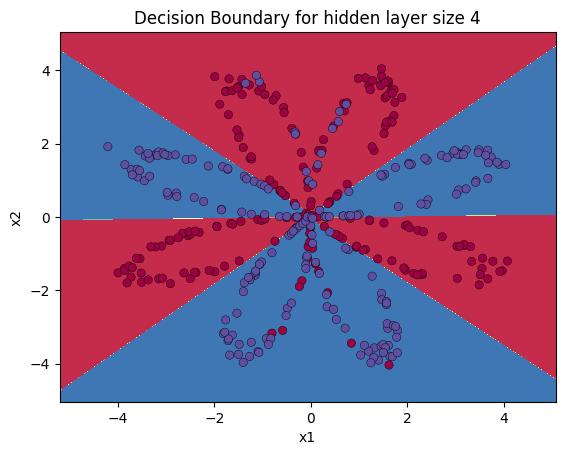

In [25]:
# Build a model with an n_h-dimensional hidden layer
parameters = nn_model(X, Y, n_h=4, num_iterations=10000, print_cost=True)

# Plot the decision boundary
plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
plt.title("Decision Boundary for hidden layer size " + str(4))
plt.show()

In [26]:
# Print accuracy
predictions = predict(parameters, X)
print('Accuracy: %d%%' % (np.mean(predictions == Y) * 100))

Accuracy: 90%


**Expected output**: `Accuracy: 90%`

The accuracy is much higher than logistic regression. The model has learned the shape of the flower's petals! Unlike logistic regression, a neural network can learn highly non-linear decision boundaries.

<a name='6'></a>
## 6 - Tuning the hidden layer size

Run the code below (it can take a minute or two). Look at how the model behaves with different hidden-layer sizes.

Accuracy for 1 hidden units: 67.50 %


Accuracy for 2 hidden units: 67.25 %


Accuracy for 3 hidden units: 90.75 %


Accuracy for 4 hidden units: 90.50 %


Accuracy for 5 hidden units: 91.25 %


Accuracy for 20 hidden units: 91.00 %


Accuracy for 50 hidden units: 90.50 %


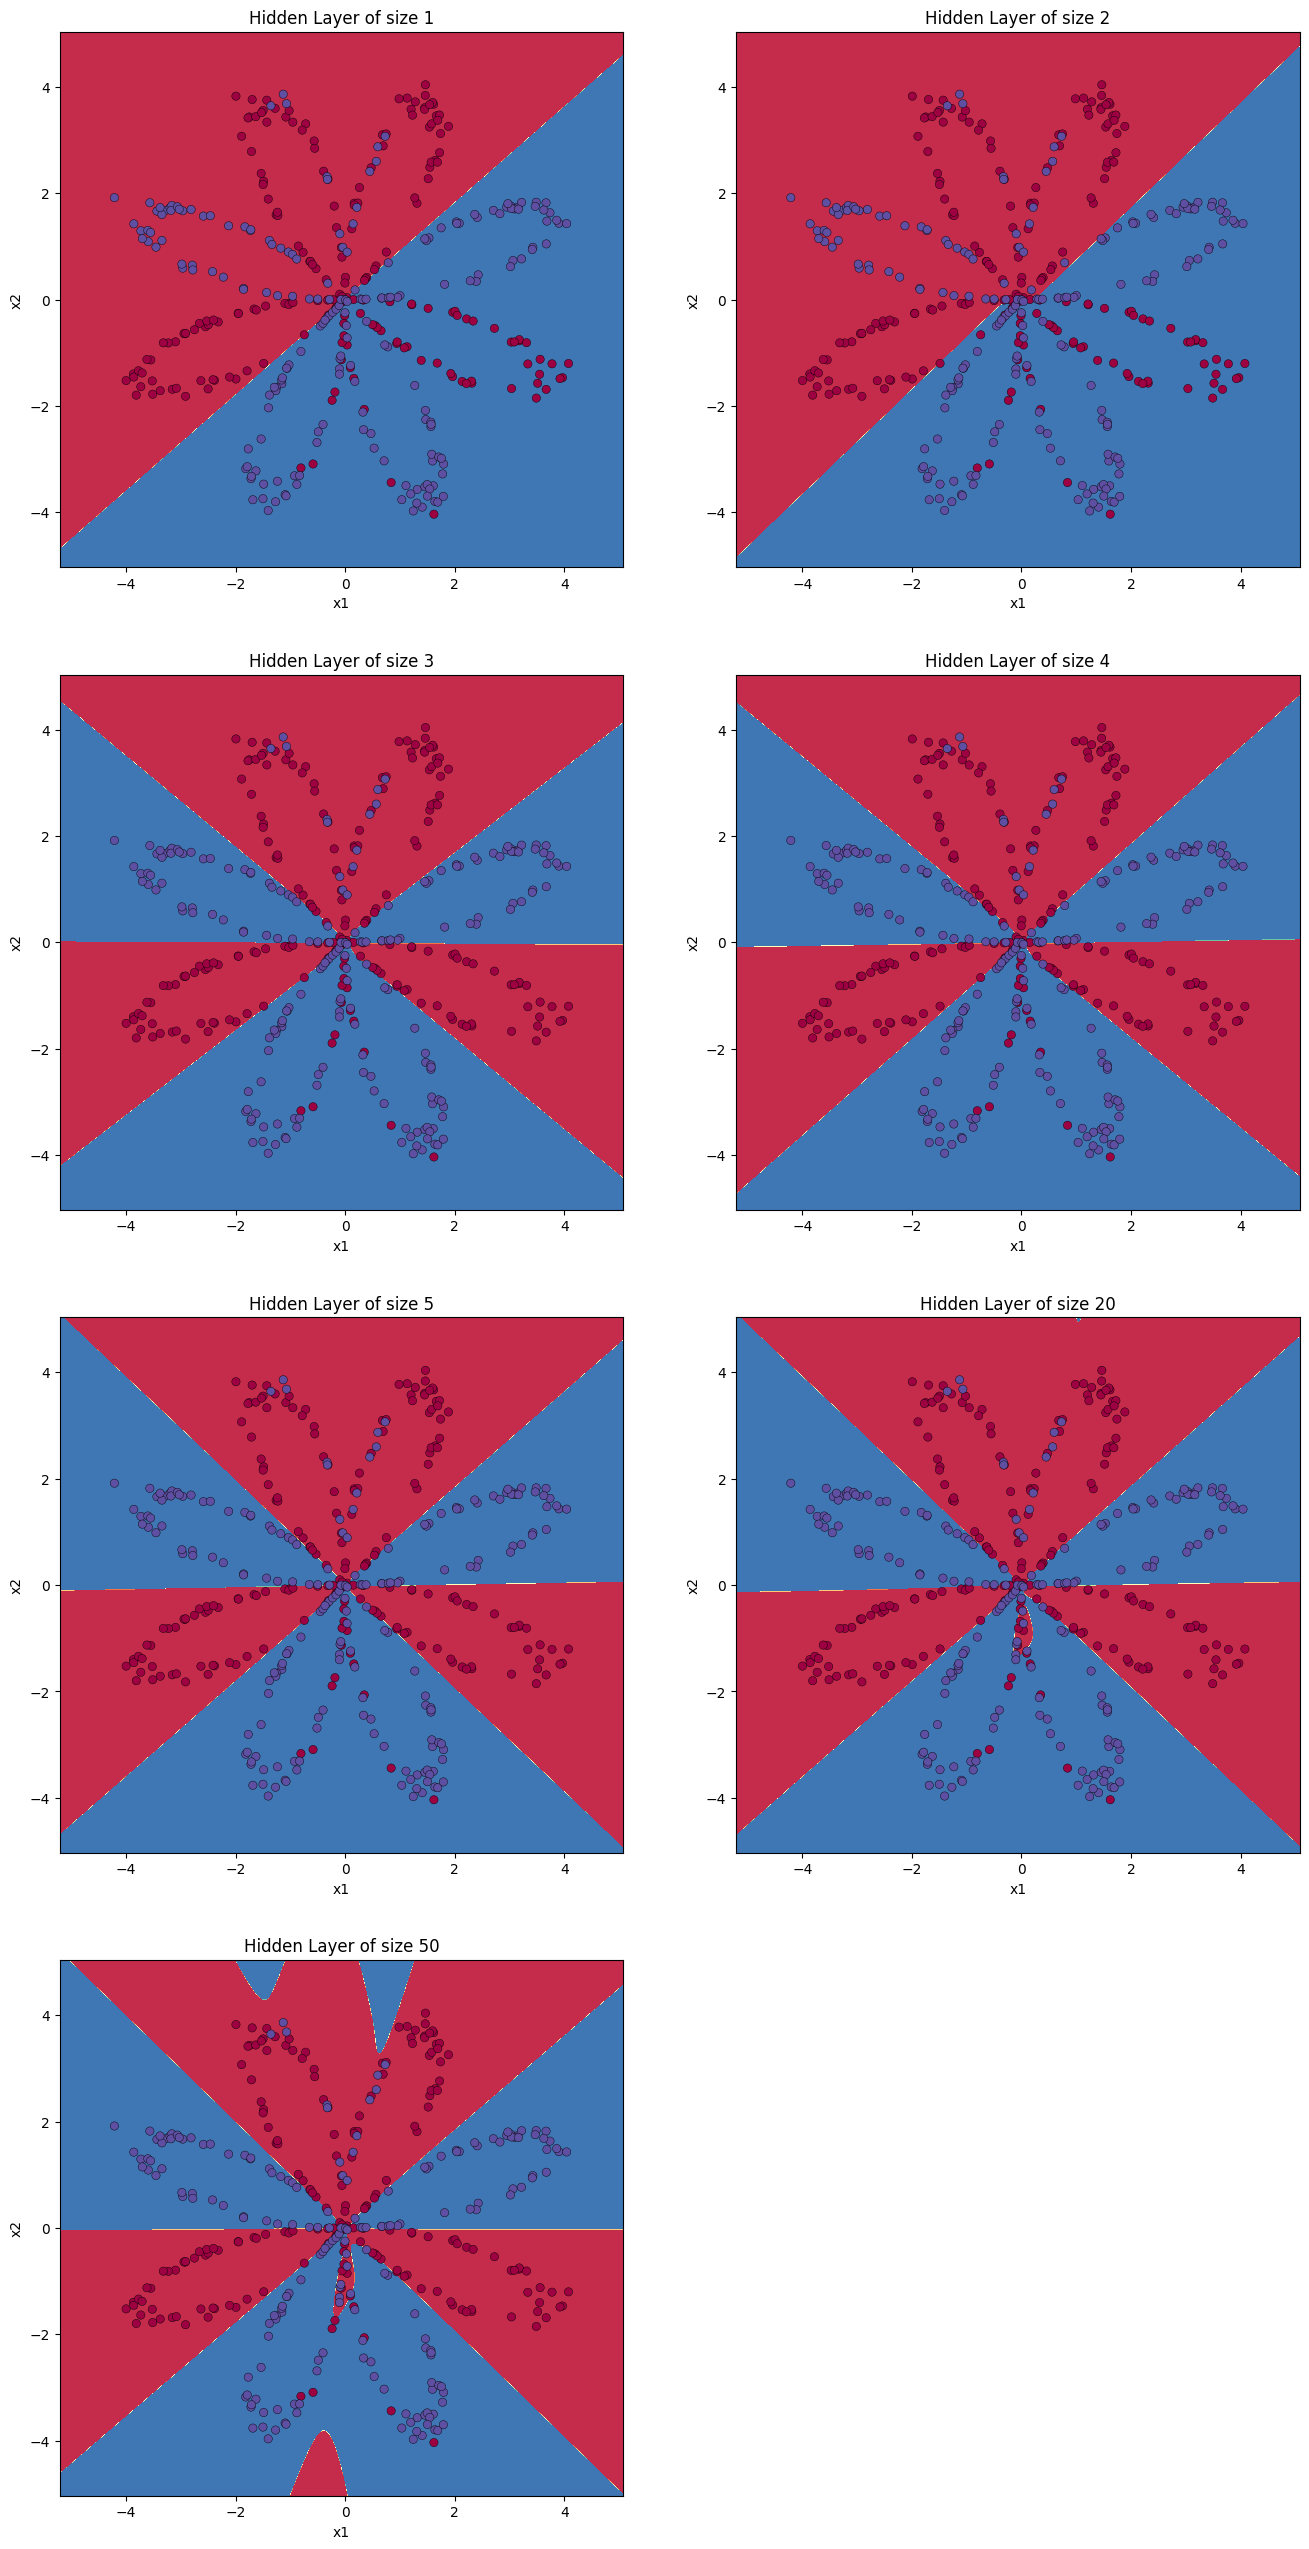

In [27]:
# This may take about 1-2 minutes to run
plt.figure(figsize=(16, 32))
hidden_layer_sizes = [1, 2, 3, 4, 5, 20, 50]

for i, n_h in enumerate(hidden_layer_sizes):
    plt.subplot(4, 2, i + 1)
    plt.title('Hidden Layer of size %d' % n_h)
    parameters = nn_model(X, Y, n_h, num_iterations=5000)
    plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
    predictions = predict(parameters, X)
    accuracy = np.mean(predictions == Y) * 100
    print("Accuracy for {} hidden units: {:.2f} %".format(n_h, accuracy))
plt.show()

**Interpretation**:
- Larger models (more hidden units) fit the training set better, until eventually the largest models overfit the data.
- The best hidden-layer size here seems to be around `n_h = 5`: it fits the data well without noticeable overfitting.
- Later in the course you will learn about **regularization**, which lets you use very large models (such as `n_h = 50`) without much overfitting.

<a name='7'></a>
## 7 - The learning rate

The code below trains the same 4-unit network with different learning rates and plots the cost after every iteration. It uses only the functions you wrote. Run it and compare the curves.

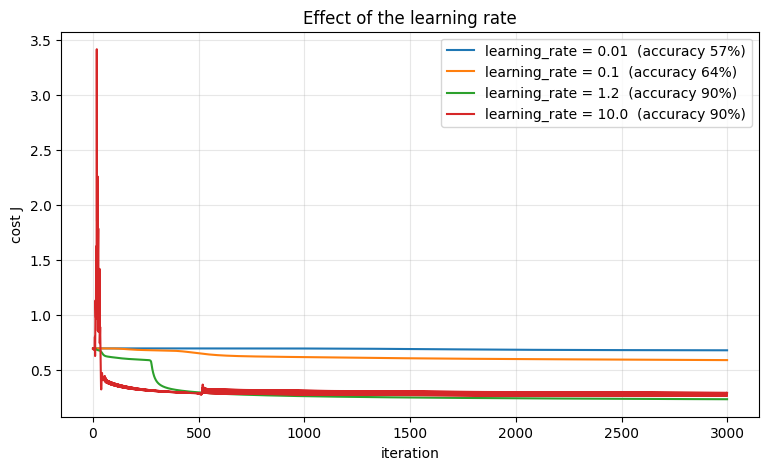

In [28]:
learning_rates = [0.01, 0.1, 1.2, 10.0]
plt.figure(figsize=(9, 5))
for lr in learning_rates:
    np.random.seed(3)
    params = initialize_parameters(2, 4, 1)
    costs = []
    for i in range(3000):
        A2, cache = forward_propagation(X, params)
        costs.append(compute_cost(A2, Y))
        grads = backward_propagation(params, cache, X, Y)
        params = update_parameters(params, grads, learning_rate=lr)
    acc = np.mean(predict(params, X) == Y) * 100
    plt.plot(costs, label=f"learning_rate = {lr}  (accuracy {acc:.0f}%)")
plt.xlabel("iteration"); plt.ylabel("cost J"); plt.title("Effect of the learning rate")
plt.legend(); plt.grid(alpha=0.3); plt.show()

**Things to try** (optional): replace `np.tanh` with a sigmoid or a ReLU in `forward_propagation` (remember to change the derivative in `backward_propagation` too). What happens?

<a name='8'></a>
## 8 - Performance on other datasets

Now try your network on other datasets. Change `dataset` in the cell below to one of `"noisy_circles"`, `"noisy_moons"`, `"blobs"` or `"gaussian_quantiles"`, then run the next two cells.

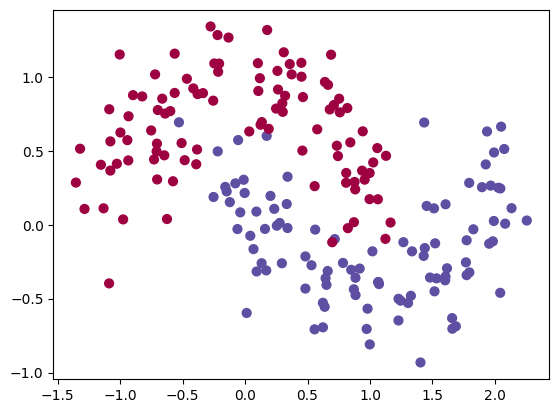

In [29]:
# Datasets
noisy_circles, noisy_moons, blobs, gaussian_quantiles = load_extra_datasets()

datasets = {"noisy_circles": noisy_circles,
            "noisy_moons": noisy_moons,
            "blobs": blobs,
            "gaussian_quantiles": gaussian_quantiles}

### CHOOSE YOUR DATASET HERE ###
dataset = "noisy_moons"
################################

X2, Y2 = datasets[dataset]
X2, Y2 = X2.T, Y2.reshape(1, Y2.shape[0])

# make blobs binary
if dataset == "blobs":
    Y2 = Y2 % 2

# Visualize the data
plt.scatter(X2[0, :], X2[1, :], c=Y2.ravel(), s=40, cmap=plt.cm.Spectral);

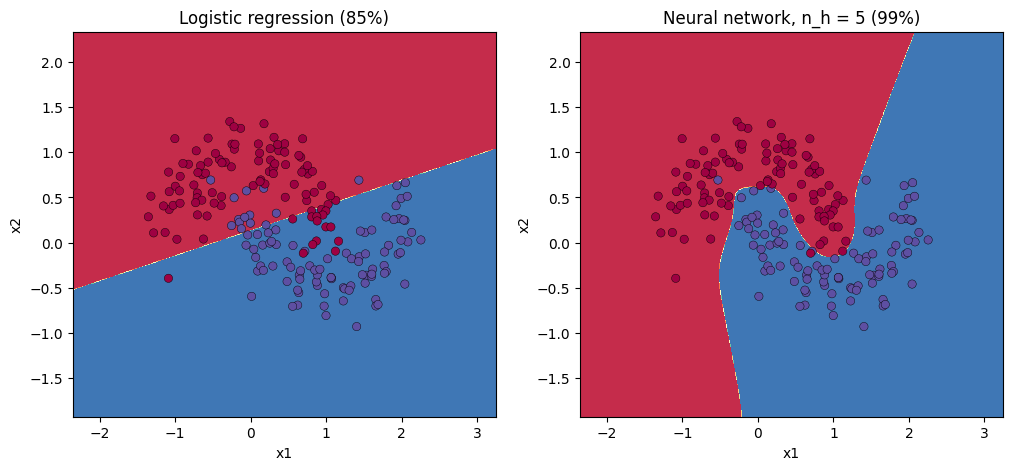

In [30]:
# Train your network on the chosen dataset and compare with logistic regression
n_h = 5
params2 = nn_model(X2, Y2, n_h=n_h, num_iterations=5000)
nn_acc = np.mean(predict(params2, X2) == Y2) * 100

clf2 = sklearn.linear_model.LogisticRegressionCV().fit(X2.T, Y2.ravel())
lr_acc = np.mean(clf2.predict(X2.T) == Y2.ravel()) * 100

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.title(f"Logistic regression ({lr_acc:.0f}%)")
plot_decision_boundary(lambda x: clf2.predict(x), X2, Y2)
plt.subplot(1, 2, 2); plt.title(f"Neural network, n_h = {n_h} ({nn_acc:.0f}%)")
plot_decision_boundary(lambda x: predict(params2, x.T), X2, Y2)
plt.show()

<a name='9'></a>
## 9 - Reflection questions

Answer each question in 2–4 sentences in the cell below it.

**Q1.** Why does logistic regression reach only about 47% accuracy on the flower dataset, while the one-hidden-layer network reaches about 90%?

*Your answer:*

Logistic regression can only draw a single straight line (a linear decision boundary), but the flower's petals of each class are interleaved, so no line can separate them and it does barely better than chance (47%). The hidden layer applies a non-linear `tanh` to several linear combinations of the inputs, and the output layer combines these, so the network can bend the boundary around the petals and reaches about 90%.

**Q2.** What would happen if you initialised all the weights to zero instead of small random values? Why?

*Your answer:*

Every hidden unit would compute exactly the same output and receive exactly the same gradient, so they would all stay identical after every update (the symmetry is never broken). The network would then behave as if it had only one hidden unit, no matter how large `n_h` is. In this network it is actually worse: with $W^{[2]} = 0$ the gradient reaching $W^{[1]}$ is zero, so $W^{[1]}$ would never move at all. Small random values break the symmetry so each unit can learn a different feature.

**Q3.** Using your results from Section 6, describe what happens as `n_h` increases. Is the model with the highest training accuracy always the best choice?

*Your answer:*

With 1–2 hidden units the model underfits (≈67% accuracy) because it can only form one or two linear cuts. From 3 units up it captures the petals (≈90.5–91.25%), and n_h = 5 gave the best accuracy here (91.25%). At 20 and 50 units the training accuracy stays about the same (91.0% and 90.5%) but the decision boundary becomes more irregular as it starts fitting noisy points. So the highest training accuracy is not automatically the best choice: a larger model can overfit and generalize worse, and model choice should be based on held-out (dev/test) performance.

**Q4.** Using the plot from Section 7, describe the effect of a learning rate that is too small and one that is too large.

*Your answer:*

A learning rate that is too small (0.01, and still 0.1) makes the cost decrease very slowly: after 3000 iterations the cost is still ≈0.68 and ≈0.59, and accuracy is only 57.5% and 63.5%. At 1.2 the cost drops quickly and smoothly to ≈0.23 (90% accuracy). A learning rate that is too large (10.0) overshoots the minimum, so the cost oscillates/jumps from iteration to iteration and ends higher (≈0.29) than with 1.2; if it is increased further it can diverge completely.

**Q5.** Which of the extra datasets in Section 8 was easiest for logistic regression, and which gave the biggest gain for the neural network? Explain why.

*Your answer:*

Noisy moons was easiest for logistic regression (85%), because the two moons are mostly separable by a single tilted line apart from where their tips overlap; the network still improved it to 99%. Gaussian quantiles gave the biggest gain for the neural network (54% → 98.5%, about +44 points): one class sits in a central disc and the other in a ring around it, so any straight line cuts through both classes, while the hidden layer can build a closed, roughly circular boundary. (Noisy circles has a similar ring shape, but its heavy noise limits even the network to 78%.)

---
### Well done!
You have:
- Built a complete 2-class neural network with one hidden layer
- Used a non-linear unit (`tanh`)
- Computed the cross-entropy loss
- Implemented forward and backward propagation and trained the network with gradient descent
- Seen how the hidden-layer size and the learning rate affect what the network learns, including overfitting.

**References**: [CS231n — Neural networks case study](https://cs231n.github.io/neural-networks-case-study/)